<a href="https://colab.research.google.com/github/khushiravtode/College-ERP/blob/main/Machine_learning_based_Online_Learning_Dropout_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving online_education_dataset.csv to online_education_dataset (1).csv


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("online_education_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (32593, 14)


,id_student,gender,region,highest_education,studied_credits,imd_band,total_clicks,avg_score,engagement_level,performance_level,risk_level,pass_flag,dropout_flag,final_result
0,11391,M,East Anglian Region,HE Qualification,240,90-100%,934.0,82.0,Medium,High,Low Risk,1,0,Pass
1,28400,F,Scotland,HE Qualification,60,20-30%,1435.0,66.4,Medium,Medium,Low Risk,1,0,Pass
2,30268,F,North Western Region,A Level or Equivalent,60,30-40%,281.0,NaN,Low,NaN,Very High Risk,0,1,Withdrawn
3,31604,F,South East Region,A Level or Equivalent,60,50-60%,2158.0,76.0,High,High,Low Risk,1,0,Pass
4,32885,F,West Midlands Region,Lower Than A Level,60,50-60%,1034.0,54.4,Medium,Medium,Low Risk,1,0,Pass


In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDropout Distribution:")
print(df["dropout_flag"].value_counts())

Columns:
['id_student', 'gender', 'region', 'highest_education', 'studied_credits', 'imd_band', 'total_clicks', 'avg_score', 'engagement_level', 'performance_level', 'risk_level', 'pass_flag', 'dropout_flag', 'final_result']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         32593 non-null  int64  
 1   gender             32593 non-null  object 
 2   region             32593 non-null  object 
 3   highest_education  32593 non-null  object 
 4   studied_credits    32593 non-null  int64  
 5   imd_band           31482 non-null  object 
 6   total_clicks       29741 non-null  float64
 7   avg_score          26727 non-null  float64
 8   engagement_level   29741 non-null  object 
 9   performance_level  26695 non-null  object 
 10  risk_level         29741 non-null  object 
 11  pass_flag      

In [ ]:
# Fill missing numerical values with median
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with mode
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled successfully!")
print(df.isnull().sum())

Missing values handled successfully!
id_student           0
gender               0
region               0
highest_education    0
studied_credits      0
imd_band             0
total_clicks         0
avg_score            0
engagement_level     0
performance_level    0
risk_level           0
pass_flag            0
dropout_flag         0
final_result         0
dtype: int64


In [ ]:
X = df.drop("dropout_flag", axis=1)
y = df["dropout_flag"]

print("Input features:", X.shape)
print("dropout_flag:", y.shape)

Input features: (32593, 13)
dropout_flag: (32593,)


In [ ]:
numeric_features = X.select_dtypes(include='number').columns
categorical_features = X.select_dtypes(include='object').columns

print("Numerical Features:", list(numeric_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['id_student', 'studied_credits', 'total_clicks', 'avg_score', 'pass_flag']
Categorical Features: ['gender', 'region', 'highest_education', 'imd_band', 'engagement_level', 'performance_level', 'risk_level', 'final_result']


In [ ]:
preprocessor = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ), categorical_features)
])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

print("Training data:", X_train.shape[0])
print("Testing data:", X_test.shape[0])

Training data: 26074
Testing data: 6519


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

In [ ]:
ml_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model)
])

In [ ]:
ml_pipeline.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
y_pred = ml_pipeline.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 100.0 %


In [ ]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1-Score:", round(f1 * 100, 2), "%")

Precision: 100.0 %
Recall: 100.0 %
F1-Score: 100.0 %


In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4486
           1       1.00      1.00      1.00      2033

    accuracy                           1.00      6519
   macro avg       1.00      1.00      1.00      6519
weighted avg       1.00      1.00      1.00      6519



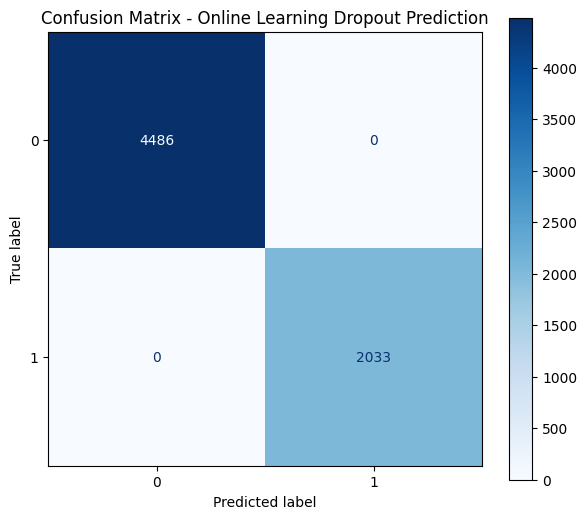

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=ml_pipeline.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Online Learning Dropout Prediction")
plt.show()

In [ ]:
feature_names = (
    ml_pipeline
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

In [ ]:
importances = (
    ml_pipeline
    .named_steps["model"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
48,cat__final_result_Withdrawn,0.414123
4,num__pass_flag,0.182142
46,cat__final_result_Fail,0.156849
47,cat__final_result_Pass,0.095602
44,cat__risk_level_Very High Risk,0.032809
2,num__total_clicks,0.027563
36,cat__engagement_level_Low,0.022887
45,cat__final_result_Distinction,0.016174
3,num__avg_score,0.014097
43,cat__risk_level_Safe,0.008849


In [ ]:
print(X.columns.tolist())

['id_student', 'gender', 'region', 'highest_education', 'studied_credits', 'imd_band', 'total_clicks', 'avg_score', 'engagement_level', 'performance_level', 'risk_level', 'pass_flag', 'final_result']


In [ ]:
new_student = X_test.iloc[[0]]

prediction = ml_pipeline.predict(new_student)

print("Predicted Student Outcome:", prediction[0])

Predicted Student Outcome: 0


In [ ]:
probabilities = ml_pipeline.predict_proba(new_student)

probability_df = pd.DataFrame(
    probabilities,
    columns=ml_pipeline.classes_
)

print(probability_df)

      0     1
0  0.99  0.01


In [ ]:
,,,